In [23]:
#!/usr/bin/env python3
import os
import scipy.io as sio
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.stats import f_oneway

# 1. Full list of session paths
session_paths = [
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clear_16_33",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clearfakemouse_15_11",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_orange_16_23",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_origgreen_14_20",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_pink_16_13",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_blue_16_03",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clearfakemouse_16_46",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clearsrealmouse_16_58",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clearsrealmouse_15_31",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clear_15_11",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_blue_14_33",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_pink_14_48",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_orange_15_00",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_origgreen_15_52",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearsrealmouse_14_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearsrealmouse_14_56",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearfakemouse_14_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_blue_15_41",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_blue_13_49",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_pink_13_59",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_clear_16_47",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_pink_16_00",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_orange_16_23",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clear_14_20",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_orange_14_10",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_origgreen_13_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_origgreen_15_29"
]

# 2. Known cup conditions, longest first so substrings match correctly
cond_patterns = sorted(
    ["clearfakemouse", "clearsrealmouse", "origgreen", "blue", "orange", "pink", "clear"],
    key=len, reverse=True
)

def parse_metadata(path):
    session = os.path.basename(path)
    date = os.path.basename(os.path.dirname(path))
    animal = session.split("_", 1)[0]
    cup = next((c for c in cond_patterns if c in session), "unknown")
    parts = session.split("_")
    time = f"{parts[-2]}:{parts[-1]}"
    return animal, cup, date, time

def load_com_array(session_path, com_relpath="COM/predict00/com3d0.mat"):
    com_file = os.path.join(session_path, com_relpath)
    mat = sio.loadmat(com_file)
    return mat["com"]  # shape (N_steps, 3)

records = []
skipped = []

for p in session_paths:
    animal, cup, date, time = parse_metadata(p)
    try:
        com = load_com_array(p)
    except Exception:
        skipped.append(p)
        continue

    # Basic stats
    x, y, z = com[:,0], com[:,1], com[:,2]
    mx, sx = x.mean(), x.std(ddof=1)
    my, sy = y.mean(), y.std(ddof=1)
    mz, sz = z.mean(), z.std(ddof=1)

    # Stepwise distances & speed
    dxyz      = np.diff(com, axis=0)
    total_dist = np.linalg.norm(dxyz, axis=1).sum()
    fps = 30.0
    dt  = 1.0 / fps   # ≈0.0333 s

    speeds    = np.linalg.norm(dxyz, axis=1) / dt# per‐step distance

    # Speed statistics
    speed_mean   = speeds.mean()
    speed_median = np.median(speeds)
    speed_std    = speeds.std(ddof=1)
    speed_max    = speeds.max()
    speed_q25    = np.percentile(speeds, 25)
    speed_q75    = np.percentile(speeds, 75)

    # Straightness index
    net_disp    = np.linalg.norm(com[-1] - com[0])
    straightness = net_disp / total_dist if total_dist > 0 else np.nan

    # Radius of gyration
    center          = com.mean(axis=0)
    rads            = np.linalg.norm(com - center, axis=1)
    radius_gyration = np.sqrt((rads**2).mean())

    # Turning‐angle statistics (exclude zero‐length steps)
    if dxyz.shape[0] >= 2:
        v1     = dxyz[:-1]
        v2     = dxyz[1:]
        n1     = np.linalg.norm(v1, axis=1)
        n2     = np.linalg.norm(v2, axis=1)
        valid  = (n1 > 0) & (n2 > 0)
        cosang = np.einsum("ij,ij->i", v1[valid], v2[valid]) / (n1[valid] * n2[valid])
        angles = np.arccos(np.clip(cosang, -1, 1))
        turn_ang_mean = angles.mean()
        turn_ang_std  = angles.std(ddof=1)
    else:
        turn_ang_mean = np.nan
        turn_ang_std  = np.nan

    # Convex‐hull area of (x,y)
    xy = com[:, :2]
    if xy.shape[0] >= 3:
        hull = ConvexHull(xy)
        hull_area = hull.volume  # in 2D, 'volume' is area
    else:
        hull_area = np.nan

    # Mean squared displacement at lag 1 and 5
    def msd_at_lag(c, lag):
        if c.shape[0] > lag:
            dif = c[lag:] - c[:-lag]
            return np.mean(np.sum(dif**2, axis=1))
        else:
            return np.nan

    msd1 = msd_at_lag(com, 1)
    msd5 = msd_at_lag(com, 5)

    records.append({
        "animal": animal,
        "cup": cup,
        "date": date,
        "time": time,
        "mean_x": mx, "std_x": sx,
        "mean_y": my, "std_y": sy,
        "mean_z": mz, "std_z": sz,
        "total_path_len": total_dist,
        "n_points": com.shape[0],
        "speed_mean": speed_mean,
        "speed_median": speed_median,
        "speed_std": speed_std,
        "speed_max": speed_max,
        "speed_q25": speed_q25,
        "speed_q75": speed_q75,
        "straightness": straightness,
        "radius_gyration": radius_gyration,
        "turn_ang_mean": turn_ang_mean,
        "turn_ang_std": turn_ang_std,
        "hull_area": hull_area,
        "msd_lag1": msd1,
        "msd_lag5": msd5,
    })

# Build DataFrame
df = pd.DataFrame.from_records(records)

# Print summaries
print(f"Processed {len(df)} sessions, skipped {len(skipped)} due to missing COM files.\n")
print("Sessions per animal:")
print(df["animal"].value_counts(), "\n")
print("Sessions per cup condition:")
print(df["cup"].value_counts(), "\n")

print("Overall feature summary:")
print(df.describe().T)

print("\nGroup means per cup for selected metrics:")
print(
    df
    .groupby("cup")[[
        "speed_mean", "straightness", "radius_gyration", "hull_area", "msd_lag1", "msd_lag5"
    ]]
    .mean()
)

# 7. ANOVA across cup conditions
metrics = [
    "speed_mean", "speed_median", "speed_std", "speed_max",
    "straightness", "radius_gyration", "hull_area", "msd_lag1", "msd_lag5"
]

print("\nANOVA across cup conditions:")
anova_rows = []
for m in metrics:
    groups = [grp[m].dropna().values for _, grp in df.groupby("cup") if len(grp[m].dropna()) > 1]
    if len(groups) > 1:
        F, p = f_oneway(*groups)
        print(f"  {m:15s}  F = {F:6.2f},  p = {p:.3f}")
        anova_rows.append({"metric": m, "F": F, "p": p})
    else:
        print(f"  {m:15s}  not enough groups")

# Optionally save results
df.to_csv("com_movement_metrics_summary.csv", index=False)
pd.DataFrame(anova_rows).to_csv("movement_metrics_anova.csv", index=False)
print("\nSaved detailed metrics to com_movement_metrics_summary.csv")
print("Saved ANOVA results to movement_metrics_anova.csv")


Processed 27 sessions, skipped 0 due to missing COM files.

Sessions per animal:
animal
newarrival1blkmarktail    8
rubbishnocap              7
rubbishcap                7
newarrival2               5
Name: count, dtype: int64 

Sessions per cup condition:
cup
clear              4
orange             4
origgreen          4
blue               4
pink               4
clearsrealmouse    4
clearfakemouse     3
Name: count, dtype: int64 

Overall feature summary:
                 count           mean           std            min  \
mean_x            27.0      23.314161     67.962601    -134.853220   
std_x             27.0     228.419849     38.739882     160.993875   
mean_y            27.0     155.678915    170.405982    -118.716400   
std_y             27.0     225.159343     47.585127     124.881853   
mean_z            27.0      12.340567      3.006553       5.332998   
std_z             27.0       9.100010      6.825462       3.145868   
total_path_len    27.0   38520.254137  11827.17699

<Figure size 640x480 with 0 Axes>

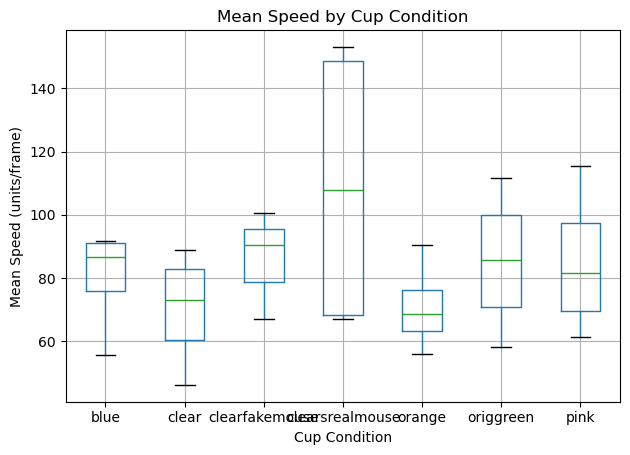

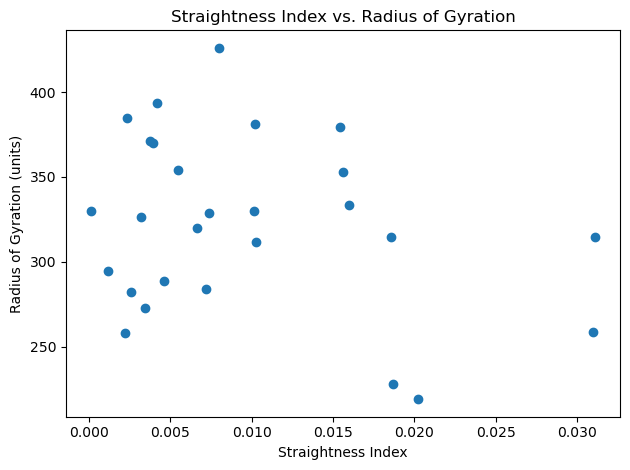

In [24]:
import matplotlib.pyplot as plt

# ——— Boxplot of mean speed by cup ———
plt.figure()
df.boxplot(column="speed_mean", by="cup")
plt.title("Mean Speed by Cup Condition")
plt.suptitle("")            # remove the automatic “Boxplot grouped by cup” title
plt.xlabel("Cup Condition")
plt.ylabel("Mean Speed (units/frame)")
plt.tight_layout()

# ——— Scatter: straightness vs. radius of gyration ———
plt.figure()
plt.scatter(df["straightness"], df["radius_gyration"])
plt.title("Straightness Index vs. Radius of Gyration")
plt.xlabel("Straightness Index")
plt.ylabel("Radius of Gyration (units)")
plt.tight_layout()

# Show both plots
plt.show()


/tmp/ipykernel_431006/1262835086.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


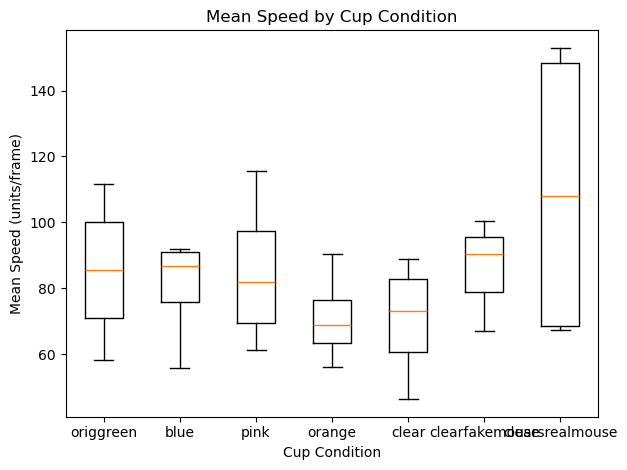

In [25]:
order = [
    "origgreen",
    "blue",
    "pink",
    "orange",
    "clear",
    "clearfakemouse",
    "clearsrealmouse"
]


import matplotlib.pyplot as plt

# Prepare one list of speed‐arrays in the exact order you want
data_in_order = [df.loc[df["cup"] == c, "speed_mean"].values for c in order]

plt.figure()
plt.boxplot(data_in_order, labels=order)
plt.title("Mean Speed by Cup Condition")
plt.xlabel("Cup Condition")
plt.ylabel("Mean Speed (units/frame)")
plt.tight_layout()
plt.show()



In [18]:
from scipy.stats import f_oneway
import itertools
import pandas as pd
import statsmodels.stats.multitest as smm

def run_anovas(df, metrics, groupby="cup"):
    """
    Perform one-way ANOVA for each metric across the groups in df[groupby].
    Returns a DataFrame with F, p, and Bonferroni-corrected p_adj.
    """
    results = []
    groups = df[groupby].unique()
    for m in metrics:
        # collect values per group
        vals = [df.loc[df[groupby]==g, m].dropna().values for g in groups]
        # only test if at least two groups have >1 sample
        if sum(len(v)>1 for v in vals) > 1:
            F, p = f_oneway(*[v for v in vals if len(v)>1])
        else:
            F, p = float("nan"), float("nan")
        results.append({"metric": m, "F": F, "p": p})
    res = pd.DataFrame(results)
    # multiple testing correction
    res["p_adj"] = smm.multipletests(res["p"].fillna(1), method="bonferroni")[1]
    return res

# usage:
metrics = ["speed_mean", "turn_ang_mean", "straightness", "radius_gyration"]
anova_df = run_anovas(df, metrics, groupby="cup")
print(anova_df)


            metric         F         p  p_adj
0       speed_mean  1.010386  0.446319    1.0
1    turn_ang_mean  0.541837  0.770277    1.0
2     straightness  0.270664  0.944207    1.0
3  radius_gyration  0.389224  0.877214    1.0


In [19]:
def segment_bouts(com, speed_thresh=1e-3):
    """
    com: np.array of shape (N,3)
    speed_thresh: minimal per-frame distance to count as motion
    Returns list of (start_idx, end_idx) for each bout of continuous movement.
    """
    speeds = np.linalg.norm(np.diff(com, axis=0), axis=1)
    moving = speeds > speed_thresh
    bouts = []
    i = 0
    while i < len(moving):
        if moving[i]:
            start = i
            while i < len(moving) and moving[i]:
                i += 1
            bouts.append((start, i))
        else:
            i += 1
    return bouts

def compute_bout_metrics(com, bouts):
    """
    Given com and list of (start,end), compute:
      - bout_count
      - mean_bout_duration (in frames)
      - mean_bout_distance (sum of speeds per bout)
    """
    dxyz = np.linalg.norm(np.diff(com, axis=0), axis=1)
    durations = []
    distances = []
    for s,e in bouts:
        durations.append(e - s)
        distances.append(dxyz[s:e].sum())
    return {
        "bout_count":      len(bouts),
        "bout_dur_mean":   np.mean(durations) if durations else np.nan,
        "bout_dist_mean":  np.mean(distances) if distances else np.nan,
    }


In [26]:
#!/usr/bin/env python3
import os
import scipy.io as sio
import numpy as np
import pandas as pd
from scipy.stats import f_oneway
import statsmodels.stats.multitest as smm

# # ——— YOUR SESSIONS ———
# session_paths = [
#     # ... (your 27 paths here) ...
# ]

# Known cup patterns, longest first
cond_patterns = sorted(
    ["clearfakemouse", "clearsrealmouse", "origgreen", "blue", "pink", "orange", "clear"],
    key=len, reverse=True
)

def parse_metadata(path):
    sess = os.path.basename(path)
    date = os.path.basename(os.path.dirname(path))
    animal = sess.split("_",1)[0]
    cup = next((c for c in cond_patterns if c in sess), "unknown")
    return animal, cup, date

def load_com(path, rel="COM/predict00/com3d0.mat"):
    mat = sio.loadmat(os.path.join(path, rel))
    return mat["com"]  # shape (T,3)

def segment_bouts(com, speed_thresh=0.5):
    speeds = np.linalg.norm(np.diff(com,axis=0),axis=1)
    moving = speeds > speed_thresh
    bouts = []
    i = 0
    while i < len(moving):
        if moving[i]:
            start = i
            while i < len(moving) and moving[i]:
                i += 1
            bouts.append((start,i))
        else:
            i += 1
    return bouts

def run_anovas(df, metrics, groupby="cup"):
    rows = []
    groups = df[groupby].unique()
    for m in metrics:
        vals = [df.loc[df[groupby]==g, m].dropna().values for g in groups]
        # require at least two groups with >1 sample
        if sum(len(v)>1 for v in vals) > 1:
            F,p = f_oneway(*(v for v in vals if len(v)>1))
        else:
            F,p = np.nan, np.nan
        rows.append({"metric":m, "F":F, "p":p})
    out = pd.DataFrame(rows)
    out["p_adj"] = smm.multipletests(out["p"].fillna(1), method="bonferroni")[1]
    return out

# ——— MAIN LOOP ———
records = []
for p in session_paths:
    animal, cup, date = parse_metadata(p)
    try:
        com = load_com(p)
    except Exception:
        continue

    # speed
    dxyz = np.diff(com,axis=0)
    speeds = np.linalg.norm(dxyz,axis=1)
    speed_mean = speeds.mean()

    # turn angle
    if dxyz.shape[0]>=2:
        v1,v2 = dxyz[:-1], dxyz[1:]
        n1,n2 = np.linalg.norm(v1,axis=1), np.linalg.norm(v2,axis=1)
        valid = (n1>0)&(n2>0)
        cosang = np.einsum("ij,ij->i", v1[valid], v2[valid])/(n1[valid]*n2[valid])
        ang = np.arccos(np.clip(cosang,-1,1))
        turn_ang_mean = ang.mean()
    else:
        turn_ang_mean = np.nan

    # straightness
    total_dist = speeds.sum()
    net_disp = np.linalg.norm(com[-1]-com[0])
    straightness = net_disp/total_dist if total_dist>0 else np.nan

    # radius of gyration
    center = com.mean(axis=0)
    rg = np.sqrt(np.mean(np.sum((com-center)**2,axis=1)))

    # bouts
    bouts = segment_bouts(com)
    dframe = np.linalg.norm(np.diff(com,axis=0),axis=1)
    durations = [e-s for s,e in bouts]
    distances = [dframe[s:e].sum() for s,e in bouts]
    bout_count     = len(bouts)
    bout_dur_mean  = np.mean(durations) if durations else np.nan
    bout_dist_mean = np.mean(distances) if distances else np.nan

    records.append({
        "animal": animal, "cup": cup, "date": date,
        "speed_mean": speed_mean,
        "turn_ang_mean": turn_ang_mean,
        "straightness": straightness,
        "radius_gyration": rg,
        "bout_count": bout_count,
        "bout_dur_mean": bout_dur_mean,
        "bout_dist_mean": bout_dist_mean,
    })

df = pd.DataFrame.from_records(records)
print(f"Processed {len(df)} sessions.\n")

# ——— RUN ANOVAS ———
metrics = [
    "speed_mean", "turn_ang_mean", "straightness",
    "radius_gyration", "bout_count", "bout_dur_mean", "bout_dist_mean"
]
anova_df = run_anovas(df, metrics, groupby="cup")
print("ANOVA results across cup conditions:")
print(anova_df.to_string(index=False))

# Optionally save
df.to_csv("session_metrics.csv", index=False)
anova_df.to_csv("session_anovas.csv", index=False)
print("\nSaved session_metrics.csv and session_anovas.csv")


Processed 27 sessions.

ANOVA results across cup conditions:
         metric        F        p  p_adj
     speed_mean 1.010386 0.446319    1.0
  turn_ang_mean 0.541837 0.770277    1.0
   straightness 0.270664 0.944207    1.0
radius_gyration 0.389224 0.877214    1.0
     bout_count 0.638726 0.698171    1.0
  bout_dur_mean 0.871068 0.533032    1.0
 bout_dist_mean 0.848091 0.548360    1.0

Saved session_metrics.csv and session_anovas.csv


/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


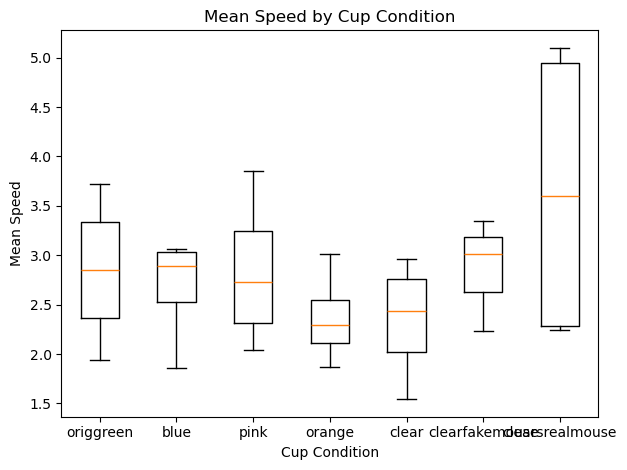

/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


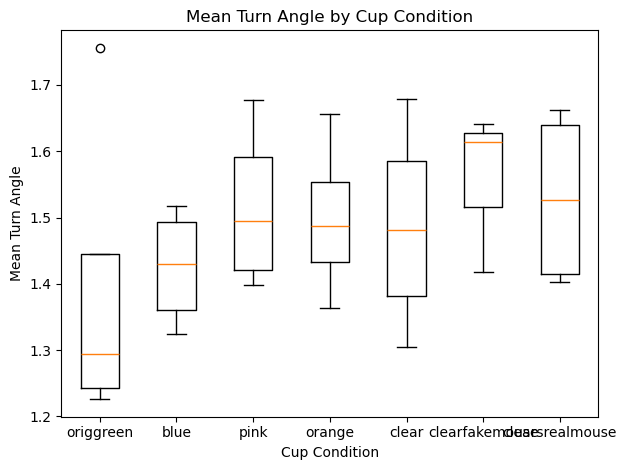

/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


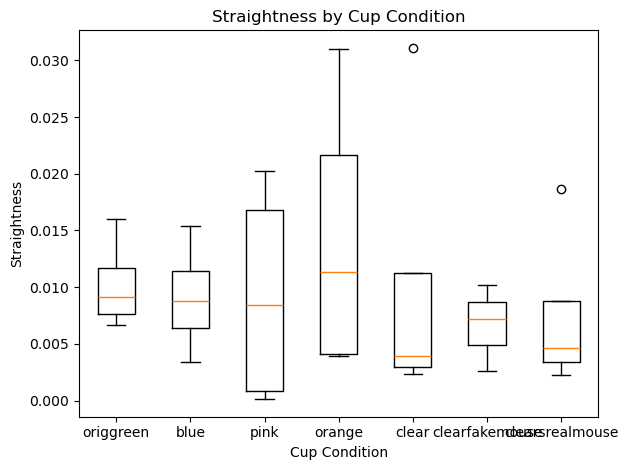

/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


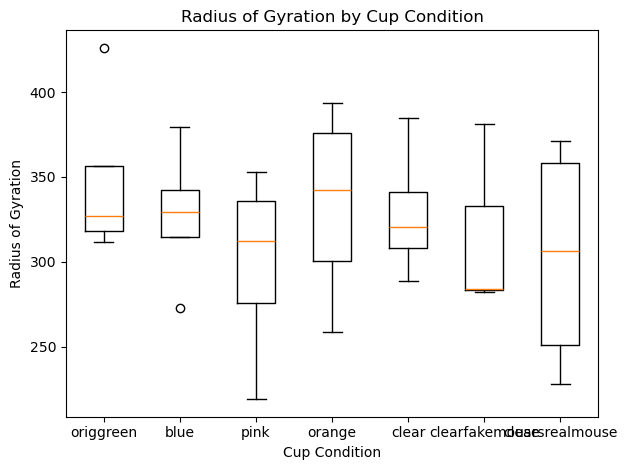

/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


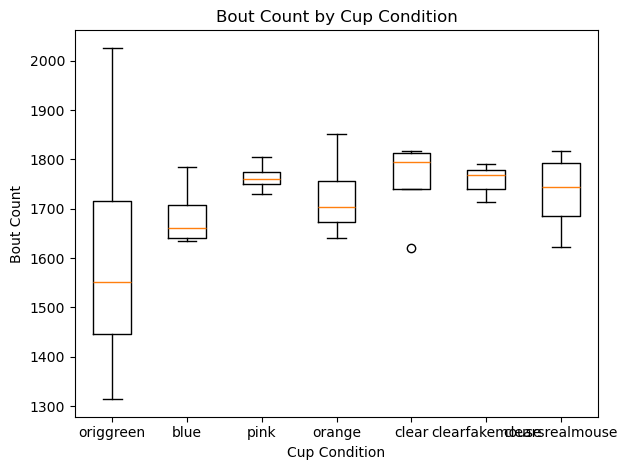

In [22]:
import matplotlib.pyplot as plt

# 1) Define your desired cup order
order = [
    "origgreen",
    "blue",
    "pink",
    "orange",
    "clear",
    "clearfakemouse",
    "clearsrealmouse"
]

# 2) Pick which metrics to visualize (you can add/remove as you like)
metrics = [
    ("Mean Speed",        "speed_mean"),
    ("Mean Turn Angle",   "turn_ang_mean"),
    ("Straightness",      "straightness"),
    ("Radius of Gyration","radius_gyration"),
    ("Bout Count",        "bout_count"),
]

# 3) Loop and plot
for title, col in metrics:
    # gather data in the specified order
    data_in_order = [df.loc[df["cup"] == c, col].dropna().values for c in order]
    
    plt.figure()
    plt.boxplot(data_in_order, labels=order)
    plt.title(f"{title} by Cup Condition")
    plt.xlabel("Cup Condition")
    plt.ylabel(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# Convert and flatten the ChunkedArray
rec_paths = filtered_table["rec_path"].to_pylist()

# Print each path
for path in rec_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    print(path[0] if isinstance(path, list) else path)


/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenecup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearecup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup
